1. Dataset Loading and Overview

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\rayen\Downloads\steam.csv\steam.csv")

print(df.shape)
print(df.head())
print(df.info())

(27075, 18)
   appid                       name release_date  english         developer  \
0     10             Counter-Strike   2000-11-01        1             Valve   
1     20      Team Fortress Classic   1999-04-01        1             Valve   
2     30              Day of Defeat   2003-05-01        1             Valve   
3     40         Deathmatch Classic   2001-06-01        1             Valve   
4     50  Half-Life: Opposing Force   1999-11-01        1  Gearbox Software   

  publisher          platforms  required_age  \
0     Valve  windows;mac;linux             0   
1     Valve  windows;mac;linux             0   
2     Valve  windows;mac;linux             0   
3     Valve  windows;mac;linux             0   
4     Valve  windows;mac;linux             0   

                                          categories  genres  \
0  Multi-player;Online Multi-Player;Local Multi-P...  Action   
1  Multi-player;Online Multi-Player;Local Multi-P...  Action   
2              Multi-player;Valv

2. Missing Value Analysis

In [2]:
print(df.isnull().sum())

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64


3. Descriptive Statistics

In [3]:
print(df.describe())

              appid       english  required_age  achievements  \
count  2.707500e+04  27075.000000  27075.000000  27075.000000   
mean   5.962035e+05      0.981127      0.354903     45.248864   
std    2.508942e+05      0.136081      2.406044    352.670281   
min    1.000000e+01      0.000000      0.000000      0.000000   
25%    4.012300e+05      1.000000      0.000000      0.000000   
50%    5.990700e+05      1.000000      0.000000      7.000000   
75%    7.987600e+05      1.000000      0.000000     23.000000   
max    1.069460e+06      1.000000     18.000000   9821.000000   

       positive_ratings  negative_ratings  average_playtime  median_playtime  \
count      2.707500e+04      27075.000000      27075.000000      27075.00000   
mean       1.000559e+03        211.027147        149.804949        146.05603   
std        1.898872e+04       4284.938531       1827.038141       2353.88008   
min        0.000000e+00          0.000000          0.000000          0.00000   
25%        6.0

In [4]:
print(df.isnull().sum())
print(df.describe())

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64
              appid       english  required_age  achievements  \
count  2.707500e+04  27075.000000  27075.000000  27075.000000   
mean   5.962035e+05      0.981127      0.354903     45.248864   
std    2.508942e+05      0.136081      2.406044    352.670281   
min    1.000000e+01      0.000000      0.000000      0.000000   
25%    4.012300e+05      1.000000      0.000000      0.000000   
50%    5.990700e+05      1.000000      0.000000      7.000000   
75%    7.987600e+05      1.000000      0.000000     23.000000   
max    1.069460e+06      1.000000     18.000000   982

4. Data Cleaning

In [5]:
df["developer"] = df["developer"].fillna("Unknown")
df["publisher"] = df["publisher"].fillna("Unknown")

5. Top 10 Games by Positive Ratings

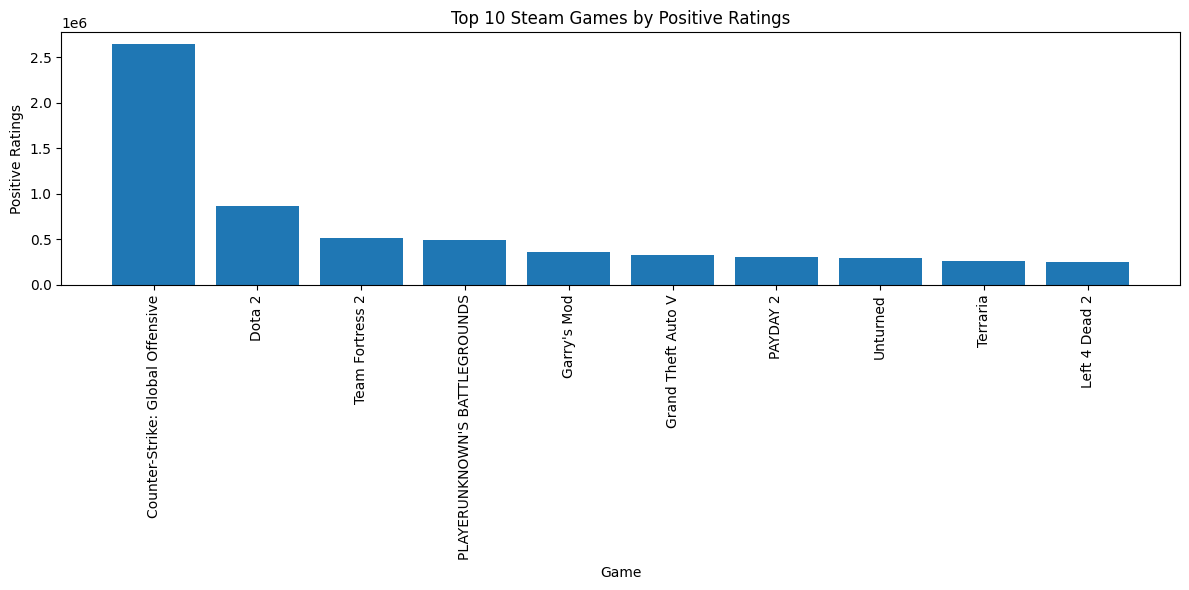

In [6]:
import matplotlib.pyplot as plt

top_games = df.sort_values(
    by="positive_ratings",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_games["name"], top_games["positive_ratings"])
plt.xticks(rotation=90)
plt.title("Top 10 Steam Games by Positive Ratings")
plt.ylabel("Positive Ratings")
plt.xlabel("Game")
plt.tight_layout()
plt.show()

6. Price Distribution Analysis

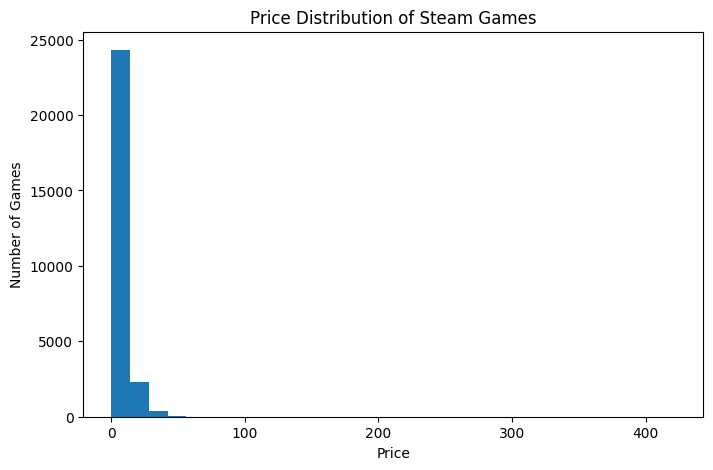

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Price Distribution of Steam Games")
plt.xlabel("Price")
plt.ylabel("Number of Games")
plt.show()

7. Price vs Positive Ratings

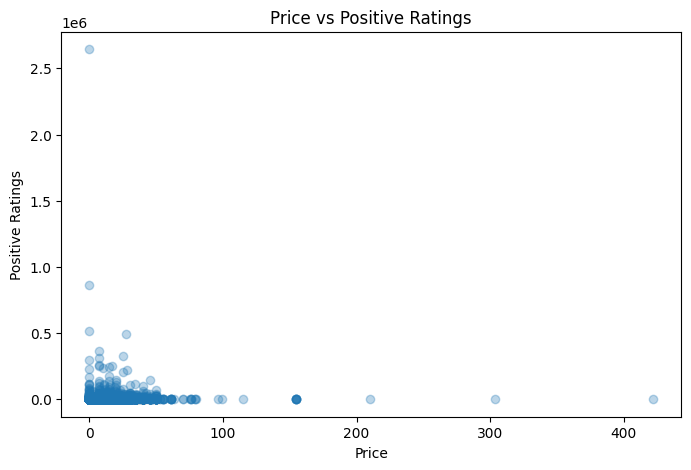

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["price"], df["positive_ratings"], alpha=0.3)
plt.title("Price vs Positive Ratings")
plt.xlabel("Price")
plt.ylabel("Positive Ratings")
plt.show()

8. Top Genres Analysis

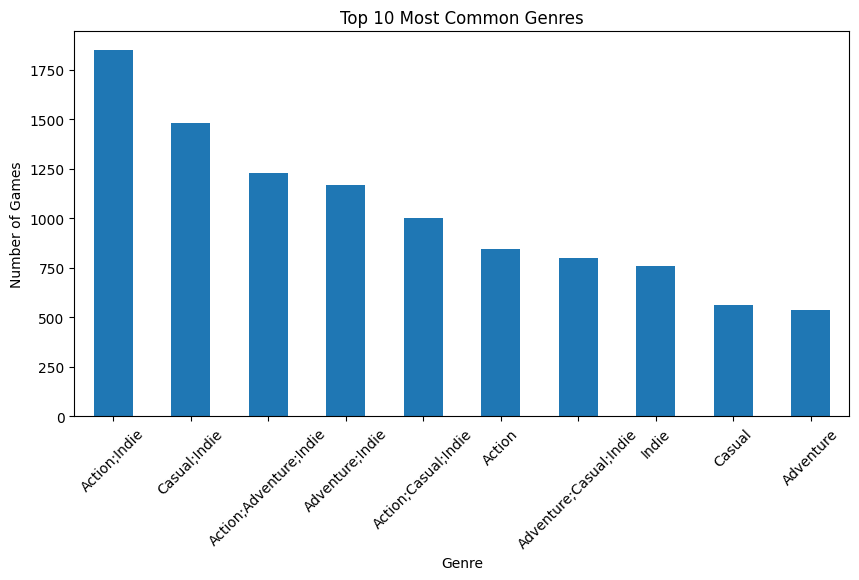

In [9]:
top_genres = df["genres"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind="bar")
plt.title("Top 10 Most Common Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.show()

9. Correlation Analysis

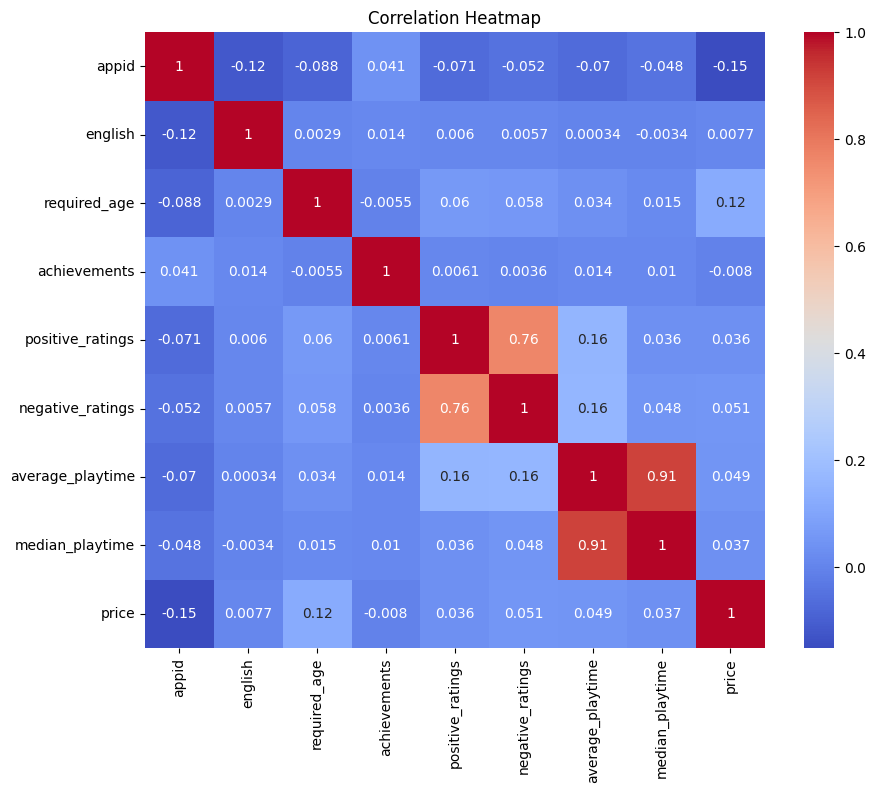

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

10. Top Publishers

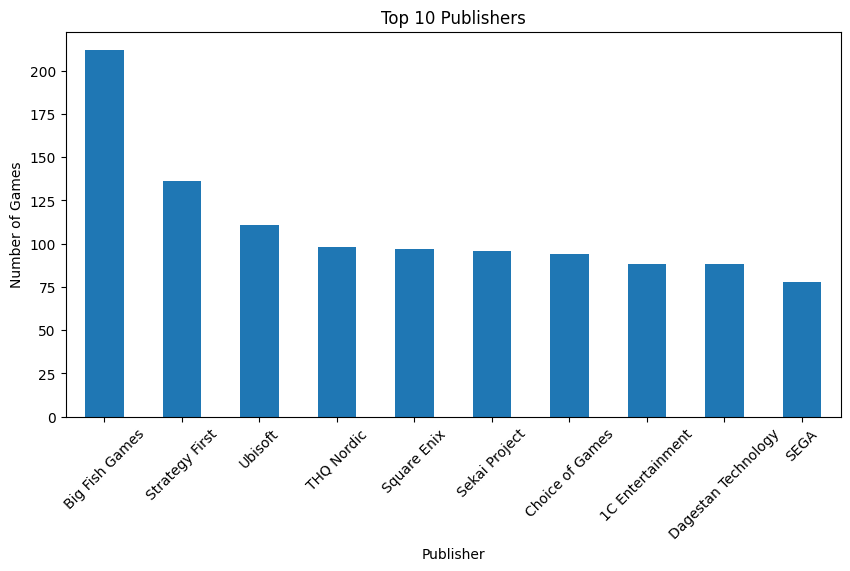

In [11]:
top_publishers = df["publisher"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_publishers.plot(kind="bar")
plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.show()

11. Average Playtime Distribution

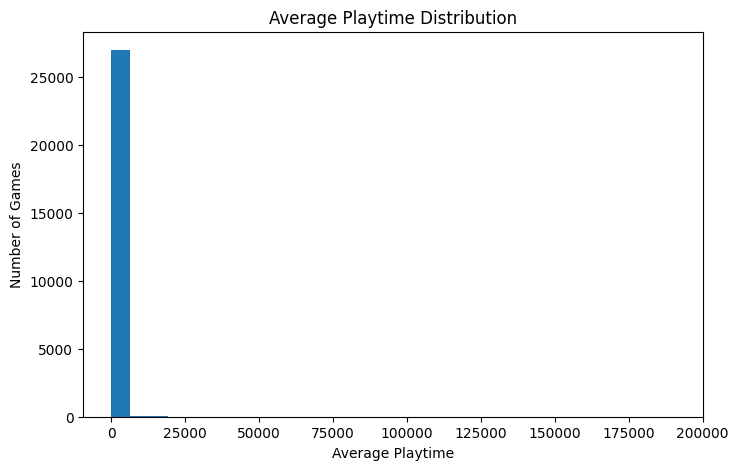

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["average_playtime"], bins=30)
plt.title("Average Playtime Distribution")
plt.xlabel("Average Playtime")
plt.ylabel("Number of Games")
plt.show()

12. Top Developers

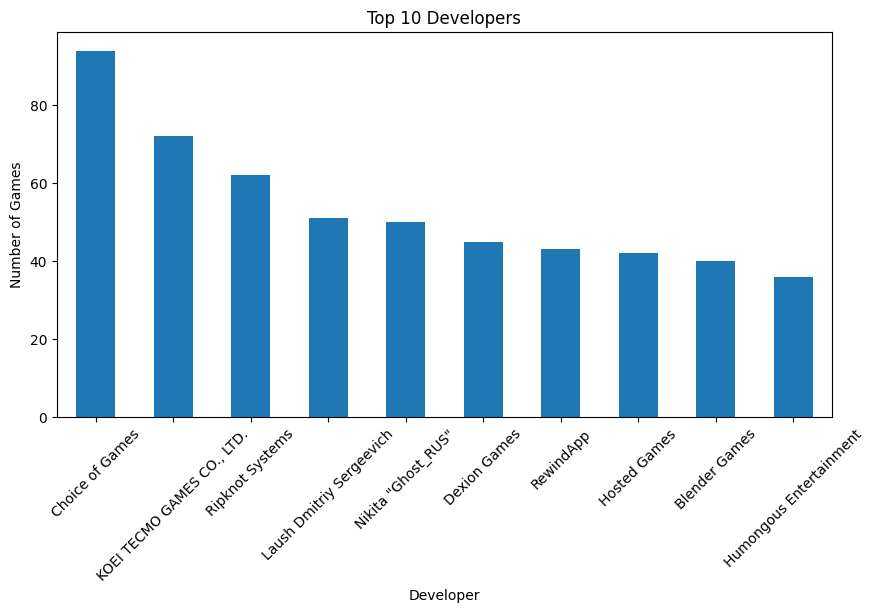

In [13]:
top_developers = df["developer"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_developers.plot(kind="bar")
plt.title("Top 10 Developers")
plt.xlabel("Developer")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.show()

13. Games Released Per Year

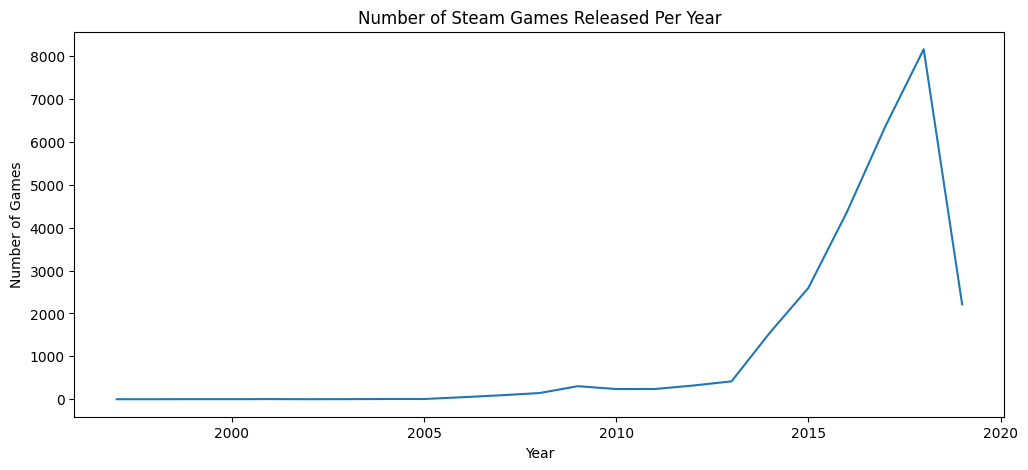

In [14]:
df["release_year"] = pd.to_datetime(df["release_date"]).dt.year

games_per_year = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
games_per_year.plot(kind="line")
plt.title("Number of Steam Games Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.show()

14. Positive Ratings vs Negative Ratings

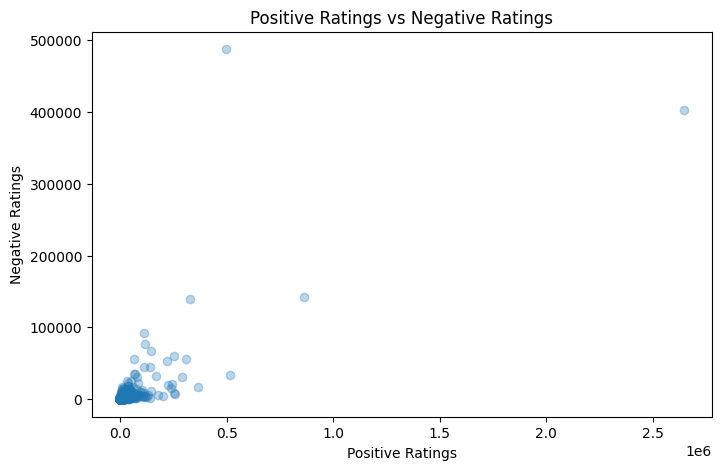

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["positive_ratings"],
    df["negative_ratings"],
    alpha=0.3
)

plt.title("Positive Ratings vs Negative Ratings")
plt.xlabel("Positive Ratings")
plt.ylabel("Negative Ratings")
plt.show()

15. Rating Ratio Calculation

In [16]:
df["rating_ratio"] = (
    df["positive_ratings"] /
    (df["positive_ratings"] + df["negative_ratings"])
)

print(df["rating_ratio"].describe())

count    27075.000000
mean         0.714478
std          0.233594
min          0.000000
25%          0.583333
50%          0.760331
75%          0.893905
max          1.000000
Name: rating_ratio, dtype: float64


16. Rating Ratio Distribution

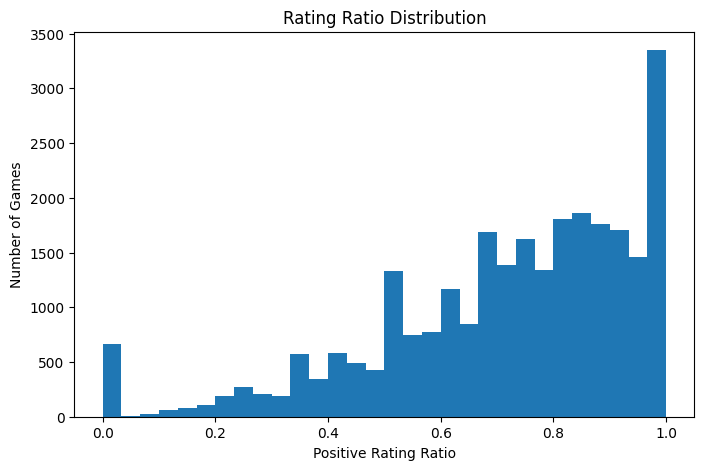

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["rating_ratio"], bins=30)
plt.title("Rating Ratio Distribution")
plt.xlabel("Positive Rating Ratio")
plt.ylabel("Number of Games")
plt.show()